The bad result is:
{}


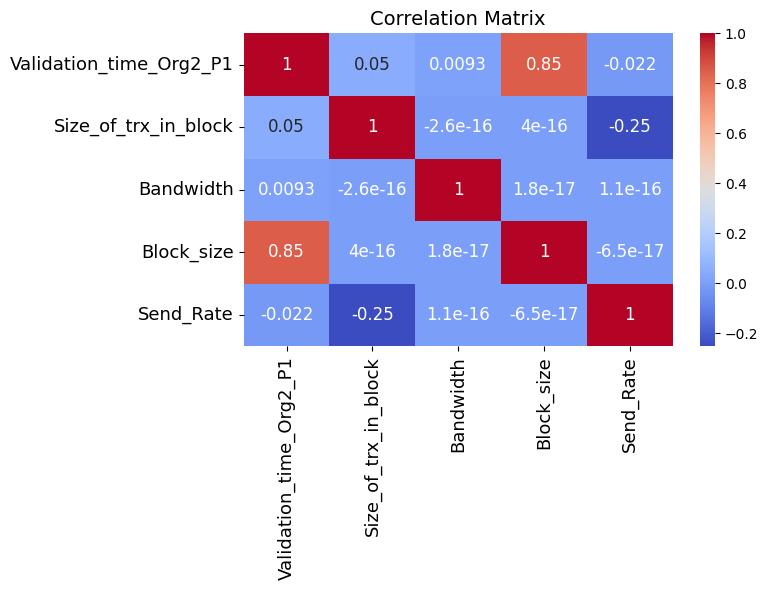

Correlation with 'Validation_time_Org2_P1':
Validation_time_Org2_P1    1.000000
Block_size                 0.850558
latancy                    0.780305
Size_of_trx_in_block       0.049548
Bandwidth                  0.009284
Send_Rate                 -0.021801
throuout                  -0.780420
Name: Validation_time_Org2_P1, dtype: float64

Feature Importances (impurity-based, fitted on train only):
            Feature  Importance
2        Block_size    0.983482
3         Send_Rate    0.007902
1         Bandwidth    0.004871
0  Transaction_Size    0.003745


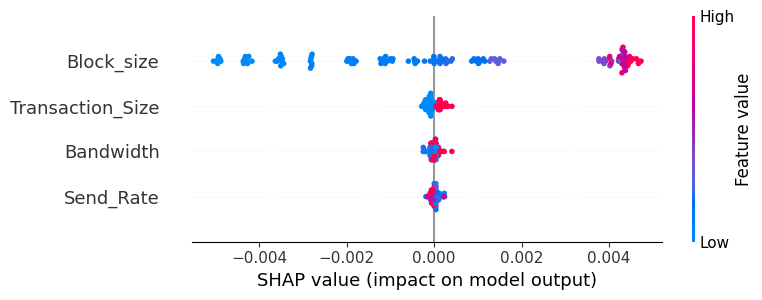

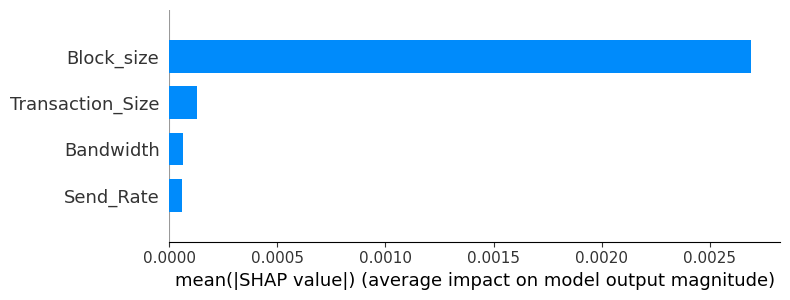


SHAP Feature Importances:
            Feature  mean_|SHAP|
2        Block_size     0.002690
0  Transaction_Size     0.000129
1         Bandwidth     0.000063
3         Send_Rate     0.000059

Top 2 Features (by SHAP):
['Block_size', 'Transaction_Size']


KeyError: "['Transaction_Size'] not in index"

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
plt.rcParams.update({'pdf.fonttype': 42})
import seaborn as sns
from sklearn.ensemble import RandomForestRegressor
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error

# ---- Your dataset ----
data = {


     "Size_of_trx_in_block": [2,2,2,2,2,2,2,2,2,2,2,2,2,2,2,
                             2,2,2,2,2,2,2,2,2,2,2,2,2,2,2,
                             2,2,2,2,2,2,2,2,2,2,2,2,2,2,2,
                             2,2,2,2,2,2,2,2,2,2,2,2,2,2,2,
                             2,2,2,2,2,2,2,2,2,2,2,2,2,2,2,
                             2,2,2,2,2,2,2,2,2,2,2,2,2,2,2,
                             2,2,2,2,2,2,2,2,2,2,2,2,2,2,2,
                             2,2,2,2,2,2,2,2,2,2,2,2,2,2,2,
                             2,2,2,2,2,2,2,2,2,2,2,2,2,2,2,
                             2,2,2,2,2,2,2,2,2,2,2,2,2,2,2,
                             2,2,2,2,2,2,2,2,2,2,2,2,2,2,2,
                             2,2,2,2,2,2,2,2,2,2,2,2,2,2,2,
                             2,2,2,2,2,2,2,2,2,2,2,2,2,2,2,
                             2,2,2,2,2,2,2,2,2,2,2,2,2,2,2,
                             2,2,2,2,2,2,2,2,2,2,2,2,2,2,2,
                             2,2,2,2,2,2,2,2,2,2,2,2,2,2,2,
                              
                            2,2,2,2,2,2,2,2,2,2,2,2,2,2,2,
                             2,2,2,2,2,2,2,2,2,2,2,2,2,2,2,
                             2,2,2,2,2,2,2,2,2,2,2,2,2,2,2,
                             2,2,2,2,2,2,2,2,2,2,2,2,2,2,2,
                             2,2,2,2,2,2,2,2,2,2,2,2,2,2,2,
                             2,2,2,2,2,2,2,2,2,2,2,2,2,2,2,
                             2,2,2,2,2,2,2,2,2,2,2,2,2,2,2,
                             2,2,2,2,2,2,2,2,2,2,2,2,2,2,2,
                              
                              4,4,4,4,4,4,4,4,4,4,4,4,4,4,4,
                               4,4,4,4,4,4,4,4,4,4,4,4,4,4,4,
                               4,4,4,4,4,4,4,4,4,4,4,4,4,4,4,
                               4,4,4,4,4,4,4,4,4,4,4,4,4,4,4,
                               4,4,4,4,4,4,4,4,4,4,4,4,4,4,4,
                               4,4,4,4,4,4,4,4,4,4,4,4,4,4,4,
                              
                              4,4,4,4,4,4,4,4,4,4,4,4,4,4,4,
                               4,4,4,4,4,4,4,4,4,4,4,4,4,4,4,
                               4,4,4,4,4,4,4,4,4,4,4,4,4,4,4,
                               4,4,4,4,4,4,4,4,4,4,4,4,4,4,4,
                               4,4,4,4,4,4,4,4,4,4,4,4,4,4,4,
                               4,4,4,4,4,4,4,4,4,4,4,4,4,4,4,
                             
                               4,4,4,4,4,4,4,4,4,4,4,4,4,4,4,
                               4,4,4,4,4,4,4,4,4,4,4,4,4,4,4,
                               4,4,4,4,4,4,4,4,4,4,4,4,4,4,4,
                               4,4,4,4,4,4,4,4,4,4,4,4,4,4,4,
                               4,4,4,4,4,4,4,4,4,4,4,4,4,4,4,
                               4,4,4,4,4,4,4,4,4,4,4,4,4,4,4,
                              
                              # 8,8,8,8,8,8,8,8,8,8,8,8,8,8,8,
                              #  8,8,8,8,8,8,8,8,8,8,8,8,8,8,8,
                              #  8,8,8,8,8,8,8,8,8,8,8,8,8,8,8,
                              #  8,8,8,8,8,8,8,8,8,8,8,8,8,8,8,
                              #  8,8,8,8,8,8,8,8,8,8,8,8,8,8,8,
                              #  8,8,8,8,8,8,8,8,8,8,8,8,8,8,8,
                              
                              #   8,8,8,8,8,8,8,8,8,8,8,8,8,8,8,
                              #  8,8,8,8,8,8,8,8,8,8,8,8,8,8,8,
                              #  8,8,8,8,8,8,8,8,8,8,8,8,8,8,8,
                              #  8,8,8,8,8,8,8,8,8,8,8,8,8,8,8,
                              #  8,8,8,8,8,8,8,8,8,8,8,8,8,8,8,
                              #  8,8,8,8,8,8,8,8,8,8,8,8,8,8,8,
                    
                             
                             
                             
                        ],
    "Bandwidth": [1.2,1.2,1.2,1.2,1.2,1.2,1.2,1.2,1.2,1.2,1.2,1.2,1.2,1.2,1.2,
                  1.2,1.2,1.2,1.2,1.2,1.2,1.2,1.2,1.2,1.2,1.2,1.2,1.2,1.2,1.2,
                  1.2,1.2,1.2,1.2,1.2,1.2,1.2,1.2,1.2,1.2,1.2,1.2,1.2,1.2,1.2,
                  1.2,1.2,1.2,1.2,1.2,1.2,1.2,1.2,1.2,1.2,1.2,1.2,1.2,1.2,1.2,
                  1.2,1.2,1.2,1.2,1.2,1.2,1.2,1.2,1.2,1.2,1.2,1.2,1.2,1.2,1.2,
                  1.2,1.2,1.2,1.2,1.2,1.2,1.2,1.2,1.2,1.2,1.2,1.2,1.2,1.2,1.2,
                  1.2,1.2,1.2,1.2,1.2,1.2,1.2,1.2,1.2,1.2,1.2,1.2,1.2,1.2,1.2,
                  1.2,1.2,1.2,1.2,1.2,1.2,1.2,1.2,1.2,1.2,1.2,1.2,1.2,1.2,1.2,
                  5,5,5,5,5,5,5,5,5,5,5,5,5,5,5,
                  5,5,5,5,5,5,5,5,5,5,5,5,5,5,5,
                  5,5,5,5,5,5,5,5,5,5,5,5,5,5,5,
                  5,5,5,5,5,5,5,5,5,5,5,5,5,5,5,
                  5,5,5,5,5,5,5,5,5,5,5,5,5,5,5,
                  5,5,5,5,5,5,5,5,5,5,5,5,5,5,5,
                  5,5,5,5,5,5,5,5,5,5,5,5,5,5,5,
                  5,5,5,5,5,5,5,5,5,5,5,5,5,5,5,
                  20,20,20,20,20,20,20,20,20,20,20,20,20,20,20,
                  20,20,20,20,20,20,20,20,20,20,20,20,20,20,20,
                  20,20,20,20,20,20,20,20,20,20,20,20,20,20,20,
                  20,20,20,20,20,20,20,20,20,20,20,20,20,20,20,
                  20,20,20,20,20,20,20,20,20,20,20,20,20,20,20,
                  20,20,20,20,20,20,20,20,20,20,20,20,20,20,20,
                  20,20,20,20,20,20,20,20,20,20,20,20,20,20,20,
                  20,20,20,20,20,20,20,20,20,20,20,20,20,20,20,
                  1.2,1.2,1.2,1.2,1.2,1.2,1.2,1.2,1.2,1.2,1.2,1.2,1.2,1.2,1.2,
                  1.2,1.2,1.2,1.2,1.2,1.2,1.2,1.2,1.2,1.2,1.2,1.2,1.2,1.2,1.2,
                  1.2,1.2,1.2,1.2,1.2,1.2,1.2,1.2,1.2,1.2,1.2,1.2,1.2,1.2,1.2,
                  1.2,1.2,1.2,1.2,1.2,1.2,1.2,1.2,1.2,1.2,1.2,1.2,1.2,1.2,1.2,
                  1.2,1.2,1.2,1.2,1.2,1.2,1.2,1.2,1.2,1.2,1.2,1.2,1.2,1.2,1.2,
                  1.2,1.2,1.2,1.2,1.2,1.2,1.2,1.2,1.2,1.2,1.2,1.2,1.2,1.2,1.2,
                   5,5,5,5,5,5,5,5,5,5,5,5,5,5,5,
                  5,5,5,5,5,5,5,5,5,5,5,5,5,5,5,
                  5,5,5,5,5,5,5,5,5,5,5,5,5,5,5,
                  5,5,5,5,5,5,5,5,5,5,5,5,5,5,5,
                  5,5,5,5,5,5,5,5,5,5,5,5,5,5,5,
                  5,5,5,5,5,5,5,5,5,5,5,5,5,5,5,
                   20,20,20,20,20,20,20,20,20,20,20,20,20,20,20,
                  20,20,20,20,20,20,20,20,20,20,20,20,20,20,20,
                  20,20,20,20,20,20,20,20,20,20,20,20,20,20,20,
                  20,20,20,20,20,20,20,20,20,20,20,20,20,20,20,
                  20,20,20,20,20,20,20,20,20,20,20,20,20,20,20,
                  20,20,20,20,20,20,20,20,20,20,20,20,20,20,20,
                  
                  #         1.2,1.2,1.2,1.2,1.2,1.2,1.2,1.2,1.2,1.2,1.2,1.2,1.2,1.2,1.2,
                  # 1.2,1.2,1.2,1.2,1.2,1.2,1.2,1.2,1.2,1.2,1.2,1.2,1.2,1.2,1.2,
                  # 1.2,1.2,1.2,1.2,1.2,1.2,1.2,1.2,1.2,1.2,1.2,1.2,1.2,1.2,1.2,
                  # 1.2,1.2,1.2,1.2,1.2,1.2,1.2,1.2,1.2,1.2,1.2,1.2,1.2,1.2,1.2,
                  # 1.2,1.2,1.2,1.2,1.2,1.2,1.2,1.2,1.2,1.2,1.2,1.2,1.2,1.2,1.2,
                  # 1.2,1.2,1.2,1.2,1.2,1.2,1.2,1.2,1.2,1.2,1.2,1.2,1.2,1.2,1.2,
                  #   5,5,5,5,5,5,5,5,5,5,5,5,5,5,5,
                  # 5,5,5,5,5,5,5,5,5,5,5,5,5,5,5,
                  # 5,5,5,5,5,5,5,5,5,5,5,5,5,5,5,
                  # 5,5,5,5,5,5,5,5,5,5,5,5,5,5,5,
                  # 5,5,5,5,5,5,5,5,5,5,5,5,5,5,5,
                  # 5,5,5,5,5,5,5,5,5,5,5,5,5,5,5,
 
                 ],
    "Block_size":[2,3,4,5,6,7,8,9,10,12,16,20,30,40,50,
                  2,3,4,5,6,7,8,9,10,12,16,20,30,40,50,
                  2,3,4,5,6,7,8,9,10,12,16,20,30,40,50,
                  2,3,4,5,6,7,8,9,10,12,16,20,30,40,50,
                  2,3,4,5,6,7,8,9,10,12,16,20,30,40,50,
                  2,3,4,5,6,7,8,9,10,12,16,20,30,40,50,
                  2,3,4,5,6,7,8,9,10,12,16,20,30,40,50,
                  2,3,4,5,6,7,8,9,10,12,16,20,30,40,50,
                  
                  2,3,4,5,6,7,8,9,10,12,16,20,30,40,50,
                  2,3,4,5,6,7,8,9,10,12,16,20,30,40,50,
                  2,3,4,5,6,7,8,9,10,12,16,20,30,40,50,
                  2,3,4,5,6,7,8,9,10,12,16,20,30,40,50,
                  2,3,4,5,6,7,8,9,10,12,16,20,30,40,50,
                  2,3,4,5,6,7,8,9,10,12,16,20,30,40,50,
                  2,3,4,5,6,7,8,9,10,12,16,20,30,40,50,
                  2,3,4,5,6,7,8,9,10,12,16,20,30,40,50,
                  
                    2,3,4,5,6,7,8,9,10,12,16,20,30,40,50,
                  2,3,4,5,6,7,8,9,10,12,16,20,30,40,50,
                  2,3,4,5,6,7,8,9,10,12,16,20,30,40,50,
                  2,3,4,5,6,7,8,9,10,12,16,20,30,40,50,
                  2,3,4,5,6,7,8,9,10,12,16,20,30,40,50,
                  2,3,4,5,6,7,8,9,10,12,16,20,30,40,50,
                  2,3,4,5,6,7,8,9,10,12,16,20,30,40,50,
                  2,3,4,5,6,7,8,9,10,12,16,20,30,40,50,
                  
                   2,3,4,5,6,7,8,9,10,12,16,20,30,40,50,
                  2,3,4,5,6,7,8,9,10,12,16,20,30,40,50,
                  2,3,4,5,6,7,8,9,10,12,16,20,30,40,50,
                  2,3,4,5,6,7,8,9,10,12,16,20,30,40,50,
                  2,3,4,5,6,7,8,9,10,12,16,20,30,40,50,
                  2,3,4,5,6,7,8,9,10,12,16,20,30,40,50,
                  
                  
                   2,3,4,5,6,7,8,9,10,12,16,20,30,40,50,
                  2,3,4,5,6,7,8,9,10,12,16,20,30,40,50,
                  2,3,4,5,6,7,8,9,10,12,16,20,30,40,50,
                  2,3,4,5,6,7,8,9,10,12,16,20,30,40,50,
                  2,3,4,5,6,7,8,9,10,12,16,20,30,40,50,
                  2,3,4,5,6,7,8,9,10,12,16,20,30,40,50,
                  
                    2,3,4,5,6,7,8,9,10,12,16,20,30,40,50,
                  2,3,4,5,6,7,8,9,10,12,16,20,30,40,50,
                  2,3,4,5,6,7,8,9,10,12,16,20,30,40,50,
                  2,3,4,5,6,7,8,9,10,12,16,20,30,40,50,
                  2,3,4,5,6,7,8,9,10,12,16,20,30,40,50,
                  2,3,4,5,6,7,8,9,10,12,16,20,30,40,50,
                  
                  #   2,3,4,5,6,7,8,9,10,12,16,20,30,40,50,
                  # 2,3,4,5,6,7,8,9,10,12,16,20,30,40,50,
                  # 2,3,4,5,6,7,8,9,10,12,16,20,30,40,50,
                  # 2,3,4,5,6,7,8,9,10,12,16,20,30,40,50,
                  # 2,3,4,5,6,7,8,9,10,12,16,20,30,40,50,
                  # 2,3,4,5,6,7,8,9,10,12,16,20,30,40,50,
                  
                  
                  #   2,3,4,5,6,7,8,9,10,12,16,20,30,40,50,
                  # 2,3,4,5,6,7,8,9,10,12,16,20,30,40,50,
                  # 2,3,4,5,6,7,8,9,10,12,16,20,30,40,50,
                  # 2,3,4,5,6,7,8,9,10,12,16,20,30,40,50,
                  # 2,3,4,5,6,7,8,9,10,12,16,20,30,40,50,
                  # 2,3,4,5,6,7,8,9,10,12,16,20,30,40,50,
                  
                 ],
    "Send_Rate":[10,10,10,10,10,10,10,10,10,10,10,10,10,10,10,
                 25,25,25,25,25,25,25,25,25,25,25,25,25,25,25,
                 50,50,50,50,50,50,50,50,50,50,50,50,50,50,50,
                 100,100,100,100,100,100,100,100,100,100,100,100,100,100,100,
                 150,150,150,150,150,150,150,150,150,150,150,150,150,150,150,
                 200, 200, 200, 200, 200, 200, 200, 200, 200, 200, 200, 200, 200, 200, 200,
                 250,250,250,250,250,250,250,250,250,250,250,250,250,250,250,
                 300,300,300,300,300,300,300,300,300,300,300,300,300,300,300,
                 
                 10,10,10,10,10,10,10,10,10,10,10,10,10,10,10,
                 25,25,25,25,25,25,25,25,25,25,25,25,25,25,25,
                 50,50,50,50,50,50,50,50,50,50,50,50,50,50,50,
                 100,100,100,100,100,100,100,100,100,100,100,100,100,100,100,
                 150,150,150,150,150,150,150,150,150,150,150,150,150,150,150,
                 200, 200, 200, 200, 200, 200, 200, 200, 200, 200, 200, 200, 200, 200, 200,
                 250,250,250,250,250,250,250,250,250,250,250,250,250,250,250,
                 300,300,300,300,300,300,300,300,300,300,300,300,300,300,300,
                 
             
                 10,10,10,10,10,10,10,10,10,10,10,10,10,10,10,
                 25,25,25,25,25,25,25,25,25,25,25,25,25,25,25,
                 50,50,50,50,50,50,50,50,50,50,50,50,50,50,50,
                 100,100,100,100,100,100,100,100,100,100,100,100,100,100,100,
                 150,150,150,150,150,150,150,150,150,150,150,150,150,150,150,
                 200, 200, 200, 200, 200, 200, 200, 200, 200, 200, 200, 200, 200, 200, 200,
                 250,250,250,250,250,250,250,250,250,250,250,250,250,250,250,
                 300,300,300,300,300,300,300,300,300,300,300,300,300,300,300,
                 
                 10,10,10,10,10,10,10,10,10,10,10,10,10,10,10,
                 25,25,25,25,25,25,25,25,25,25,25,25,25,25,25,
                 50,50,50,50,50,50,50,50,50,50,50,50,50,50,50,
                 100,100,100,100,100,100,100,100,100,100,100,100,100,100,100,
                 150,150,150,150,150,150,150,150,150,150,150,150,150,150,150,
                 200, 200, 200, 200, 200, 200, 200, 200, 200, 200, 200, 200, 200, 200, 200,
                 
                  10,10,10,10,10,10,10,10,10,10,10,10,10,10,10,
                 25,25,25,25,25,25,25,25,25,25,25,25,25,25,25,
                 50,50,50,50,50,50,50,50,50,50,50,50,50,50,50,
                 100,100,100,100,100,100,100,100,100,100,100,100,100,100,100,
                 150,150,150,150,150,150,150,150,150,150,150,150,150,150,150,
                 200, 200, 200, 200, 200, 200, 200, 200, 200, 200, 200, 200, 200, 200, 200,
                 
                    10,10,10,10,10,10,10,10,10,10,10,10,10,10,10,
                 25,25,25,25,25,25,25,25,25,25,25,25,25,25,25,
                 50,50,50,50,50,50,50,50,50,50,50,50,50,50,50,
                 100,100,100,100,100,100,100,100,100,100,100,100,100,100,100,
                 150,150,150,150,150,150,150,150,150,150,150,150,150,150,150,
                 200, 200, 200, 200, 200, 200, 200, 200, 200, 200, 200, 200, 200, 200, 200,
                 
                 #  10,10,10,10,10,10,10,10,10,10,10,10,10,10,10,
                 # 25,25,25,25,25,25,25,25,25,25,25,25,25,25,25,
                 # 50,50,50,50,50,50,50,50,50,50,50,50,50,50,50,
                 # 100,100,100,100,100,100,100,100,100,100,100,100,100,100,100,
                 # 150,150,150,150,150,150,150,150,150,150,150,150,150,150,150,
                 # 200, 200, 200, 200, 200, 200, 200, 200, 200, 200, 200, 200, 200, 200, 200,
                 
                 # 10,10,10,10,10,10,10,10,10,10,10,10,10,10,10,
                 # 25,25,25,25,25,25,25,25,25,25,25,25,25,25,25,
                 # 50,50,50,50,50,50,50,50,50,50,50,50,50,50,50,
                 # 100,100,100,100,100,100,100,100,100,100,100,100,100,100,100,
                 # 150,150,150,150,150,150,150,150,150,150,150,150,150,150,150,
                 # 200, 200, 200, 200, 200, 200, 200, 200, 200, 200, 200, 200, 200, 200, 200,
             
             
                ],


     
       "Validation_time_Org2_P1": [

0.001876117,
0.002379039,
0.002990489,
0.004097087,
0.004955515,
0.005540165,
0.006216175,
0.006871859,
0.007717193,
0.007313151,
0.007951588,
0.010208368,
0.010551084,
0.010765334,
0.012148543,
0.002194578,
0.0033248,
0.003735609,
0.004610435,
0.005561183,
0.006726814,
0.007493021,
0.007854122,
0.00854994,
0.008463475,
0.008820473,
0.010244117,
0.010760602,
0.010874475,
0.010634046,
0.001754246,
0.002353918,
0.003076225,
0.003854488,
0.004742626,
0.005858106,
0.006336351,
0.006640126,
0.008249278,
0.006684129,
0.007943452,
0.010607049,
0.009667891,
0.009827349,
0.010825163,
0.001733605,
0.002531632,
0.003231466,
0.00367755,
0.004738037,
0.005304686,
0.006168792,
0.006353153,
0.007961227,
0.006995994,
0.008239919,
0.010464517,
0.011714287,
0.009989323,
0.011034467,
0.001787124,
0.002485667,
0.003042681,
0.003945716,
0.005189753,
0.005678863,
0.005901,
0.007705849,
0.00787606,
0.006918523,
0.008557531,
0.010427374,
0.010231548,
0.010305737,
0.010818826,
0.001770518,
0.002443352,
0.003137466,
0.003837133,
0.004685294,
0.005442014,
0.006465653,
0.006745537,
0.008301809,
0.006301533,
0.008390253,
0.010708933,
0.010622918,
0.011059753,
0.010875737,
0.001833412,
0.002470518,
0.003019464,
0.003917042,
0.004783846,
0.005748942,
0.006075176,
0.006824525,
0.008050893,
0.0069359,
0.008128521,
0.009829215,
0.011245927,
0.010698415,
0.011748949,
0.001799722,
0.002504044,
0.003182044,
0.003825242,
0.005141783,
0.005290643,
0.006680426,
0.007405601,
0.00805246,
0.006714462,
0.008540334,
0.009809766,
0.011016689,
0.010640319,
0.011412098,
0.001715318,
0.002432918,
0.003256114,
0.003998389,
0.004688334,
0.005062306,
0.006334331,
0.006556211,
0.007703414,
0.006540284,
0.007707594,
0.01041147,
0.010508363,
0.010068256,
0.011088955,
0.001773966,
0.002393449,
0.003265191,
0.00403662,
0.004627584,
0.005626166,
0.006183938,
0.007080907,
0.00799177,
0.006346273,
0.007529568,
0.010766945,
0.011543461,
0.010525839,
0.011275293,
0.001773966,
0.002393449,
0.003265191,
0.00403662,
0.004627584,
0.005626166,
0.006183938,
0.007080907,
0.00799177,
0.006346273,
0.007529568,
0.010766945,
0.011543461,
0.010525839,
0.011275293,
0.001736331,
0.002373111,
0.003059869,
0.003698939,
0.004811378,
0.005655667,
0.006072742,
0.007065284,
0.007983251,
0.007200934,
0.008080299,
0.010506055,
0.010911781,
0.010796236,
0.011262021,
0.001819294,
0.002459107,
0.003271929,
0.003943436,
0.004665447,
0.005363109,
0.005595951,
0.006428557,
0.007240577,
0.006381587,
0.008067157,
0.010483255,
0.010851145,
0.010244801,
0.011306818,
0.001780317,
0.002406531,
0.003326711,
0.0039781,
0.004694422,
0.005315872,
0.006713442,
0.006910467,
0.008138137,
0.007482985,
0.007739224,
0.011789304,
0.01095014,
0.010123178,
0.010787564,
0.001860336,
0.002492499,
0.003210603,
0.003821023,
0.004970287,
0.005313483,
0.006735743,
0.006923399,
0.007056973,
0.006638486,
0.008053357,
0.009968106,
0.011385058,
0.010974199,
0.01020049,
0.00171887,
0.002459709,
0.003152854,
0.00376029,
0.004623631,
0.005660612,
0.005902723,
0.006831173,
0.007322207,
0.007029082,
0.007973219,
0.010172154,
0.01114651,
0.010392072,
0.011344514,
0.001944461,
0.002441655,
0.003485889,
0.003818435,
0.004849091,
0.005688174,
0.007362475,
0.007066634,
0.007708887,
0.00727198,
0.007632133,
0.010291076,
0.012378476,
0.010339562,
0.011565561,
0.00171194,
0.002506091,
0.003203437,
0.004059849,
0.004600235,
0.005734602,
0.006359409,
0.006536149,
0.00760394,
0.006135967,
0.007886552,
0.010433975,
0.011039549,
0.011247087,
0.011769149,
0.002055061,
0.002570348,
0.003378375,
0.004474168,
0.005047222,
0.005993317,
0.006333691,
0.006963757,
0.007670467,
0.00728073,
0.008111671,
0.010371819,
0.011111085,
0.01214027,
0.011865623,
0.001872894,
0.002569868,
0.003354227,
0.00396216,
0.005227503,
0.005908979,
0.006350889,
0.006629774,
0.007957297,
0.007288203,
0.008284713,
0.010492613,
0.012578031,
0.010566978,
0.011080281,
0.001763276,
0.002369943,
0.003202591,
0.003777165,
0.005072857,
0.005560652,
0.006174019,
0.007411283,
0.007511147,
0.00701235,
0.008467094,
0.010482986,
0.009625773,
0.01173842,
0.010437119,
0.001845044,
0.002483762,
0.00332956,
0.003680379,
0.004845692,
0.00493856,
0.005873422,
0.006423266,
0.007755114,
0.007294393,
0.007917682,
0.010712126,
0.011127745,
0.011861324,
0.011027631,
0.00174369,
0.002452649,
0.003250766,
0.003694055,
0.005012822,
0.005536135,
0.007113627,
0.006368229,
0.007100905,
0.007229982,
0.008173059,
0.010966878,
0.01126768,
0.011982793,
0.012665443,
0.001751784,
0.002508784,
0.003248148,
0.003810918,
0.004915035,
0.005425646,
0.006420347,
0.006995821,
0.008309378,
0.007368997,
0.007501597,
0.010553224,
0.010429492,
0.010890644,
0.012144314,
0.001814874,
0.002637763,
0.003445879,
0.004150759,
0.005110756,
0.005932352,
0.006856845,
0.007385789,
0.008168257,
0.007518052,
0.008350686,
0.01163168,
0.01074444,
0.011450953,
0.012000308,
0.00185883,
0.002542103,
0.003527549,
0.004203049,
0.005247739,
0.005953676,
0.005642409,
0.007006861,
0.008075078,
0.007335257,
0.008097641,
0.011078842,
0.010735939,
0.011978496,
0.011508319,
0.001893785,
0.002672044,
0.003485279,
0.004340305,
0.005441771,
0.00574099,
0.006824969,
0.007156724,
0.008075792,
0.007617325,
0.008454602,
0.010818804,
0.011892096,
0.010671625,
0.011623312,
0.001969879,
0.002698267,
0.003254113,
0.004272477,
0.004845008,
0.00595861,
0.006620726,
0.007142734,
0.008190258,
0.00804829,
0.008394331,
0.010806595,
0.0116403,
0.012073574,
0.013408656,
0.001864771,
0.002675045,
0.003366201,
0.004116115,
0.005298187,
0.006066803,
0.006457638,
0.006873637,
0.007742385,
0.00730687,
0.008618409,
0.01095451,
0.011652114,
0.011898352,
0.01277547,
0.001903916,
0.002692285,
0.003682137,
0.00392099,
0.005095499,
0.005650222,
0.006186907,
0.006706296,
0.007673713,
0.007769788,
0.008567192,
0.011009143,
0.011554633,
0.010812525,
0.011322021,
0.001859858,
0.002796474,
0.003412877,
0.003975434,
0.00527072,
0.006153909,
0.005997845,
0.006886751,
0.007684323,
0.007380557,
0.008050832,
0.010713226,
0.010889063,
0.010869694,
0.010585135,
0.001870592,
0.002558879,
0.003426228,
0.004054185,
0.005009345,
0.005931611,
0.00635141,
0.008085702,
0.009061444,
0.007021065,
0.008922427,
0.011296897,
0.012403852,
0.01129505,
0.011936174,
0.001971793,
0.002606193,
0.003345803,
0.003969302,
0.005005167,
0.006120523,
0.006611194,
0.008444656,
0.007958292,
0.008235855,
0.008753074,
0.011521686,
0.011865743,
0.010786626,
0.011190312,
0.002053452,
0.002726591,
0.003338556,
0.00392021,
0.005277868,
0.005531798,
0.006040493,
0.00660954,
0.007724742,
0.007481761,
0.008298737,
0.011225555,
0.011106206,
0.011615541,
0.011140645,
0.001913048,
0.002552982,
0.003377891,
0.004063503,
0.005217226,
0.005654717,
0.006464755,
0.006724974,
0.007369916,
0.007677226,
0.008153322,
0.011248853,
0.012253314,
0.010997126,
0.011028558,
0.001844321,
0.002484696,
0.003165723,
0.004394874,
0.005385843,
0.00574259,
0.006713381,
0.006575121,
0.007625118,
0.006886938,
0.009092845,
0.01205648,
0.010803689,
0.011410279,
0.011224031,
0.001835147,
0.002566158,
0.003367471,
0.0040023,
0.005411127,
0.005610978,
0.006505467,
0.007550899,
0.00772867,
0.007266736,
0.008363099,
0.011118657,
0.011052109,
0.011339003,
0.01109829,
0.001909563,
0.002701557,
0.003571592,
0.004106788,
0.005300355,
0.006396259,
0.006968438,
0.006959753,
0.007632843,
0.007267242,
0.008863799,
0.011666874,
0.01215094,
0.013083525,
0.01201143,
0.001887432,
0.002609403,
0.003436996,
0.004076503,
0.005227057,
0.00569299,
0.006442105,
0.006519389,
0.00786768,
0.006826447,
0.008361808,
0.011880069,
0.012100503,
0.01212394,
0.011591915,
0.002029546,
0.002731797,
0.003395287,
0.004967638,
0.005812694,
0.00617648,
0.006859002,
0.007108611,
0.007498792,
0.008049504,
0.009541291,
0.01220299,
0.010583913,
0.011120178,
0.011195428,
0.001928658,
0.002613199,
0.003349008,
0.004025652,
0.005063498,
0.005920125,
0.006274045,
0.006810472,
0.007469074,
0.006761118,
0.00820314,
0.010901264,
0.011292461,
0.011728099,
0.012081719,
0.001933719,
0.002477356,
0.003286071,
0.004135234,
0.004734345,
0.00590564,
0.006968125,
0.007066937,
0.007962905,
0.00723856,
0.00819816,
0.010746477,
0.011248044,
0.010849012,
0.010494951,
# 0.002262319,
# 0.003105849,
# 0.004136809,
# 0.004574187,
# 0.005875004,
# 0.006627616,
# 0.0073855,
# 0.007452953,
# 0.008762892,
# 0.00825076,
# 0.009793685,
# 0.012159491,
# 0.012524434,
# 0.011774635,
# 0.011973585,
# 0.002181061,
# 0.00285755,
# 0.003758522,
# 0.004368854,
# 0.005885349,
# 0.006728554,
# 0.007739897,
# 0.008646177,
# 0.009221321,
# 0.008018059,
# 0.009524353,
# 0.012573003,
# 0.012205898,
# 0.012273145,
# 0.012231781,
# 0.002136319,
# 0.002835128,
# 0.003885321,
# 0.004740664,
# 0.005446376,
# 0.006253524,
# 0.007109637,
# 0.007458824,
# 0.008478866,
# 0.00815914,
# 0.009150647,
# 0.012603342,
# 0.011657666,
# 0.011073367,
# 0.011464734,
# 0.002119543,
# 0.002867117,
# 0.003897936,
# 0.004604922,
# 0.005167186,
# 0.006406498,
# 0.006808473,
# 0.007897892,
# 0.008584366,
# 0.008106007,
# 0.009927538,
# 0.011995486,
# 0.011146173,
# 0.011373485,
# 0.012316921,
# 0.002115498,
# 0.002998457,
# 0.00393369,
# 0.004756379,
# 0.005994147,
# 0.005910162,
# 0.006874242,
# 0.00726663,
# 0.007929963,
# 0.008255927,
# 0.009556916,
# 0.01231677,
# 0.011572256,
# 0.012029088,
# 0.011610488,
# 0.002205543,
# 0.003019418,
# 0.003877191,
# 0.004879372,
# 0.005504077,
# 0.006494037,
# 0.007184814,
# 0.007232931,
# 0.008115318,
# 0.007664093,
# 0.009651544,
# 0.01320297,
# 0.010959068,
# 0.011504641,
# 0.012432299,
# 0.002174299,
# 0.003752867,
# 0.00413791,
# 0.0044579,
# 0.005336655,
# 0.0064269,
# 0.006648235,
# 0.007823488,
# 0.008645515,
# 0.008319538,
# 0.009114081,
# 0.012448773,
# 0.011325744,
# 0.011006048,
# 0.011856287,
# 0.002192743,
# 0.003040074,
# 0.003810462,
# 0.004957257,
# 0.005511521,
# 0.006189274,
# 0.006478001,
# 0.007223128,
# 0.007936933,
# 0.008385409,
# 0.009565347,
# 0.012457787,
# 0.011284765,
# 0.011656104,
# 0.011395116,
# 0.002091196,
# 0.002848733,
# 0.003583292,
# 0.004251931,
# 0.005338574,
# 0.006862643,
# 0.007184712,
# 0.007704843,
# 0.008053523,
# 0.007818216,
# 0.009835803,
# 0.012465946,
# 0.012700262,
# 0.011692846,
# 0.012175853,
# 0.002107102,
# 0.002907724,
# 0.003599881,
# 0.00454423,
# 0.005920903,
# 0.006160839,
# 0.006485938,
# 0.008079444,
# 0.007981749,
# 0.00823489,
# 0.009293203,
# 0.012477883,
# 0.011462218,
# 0.012001102,
# 0.012114418,
# 0.00216496,
# 0.002937184,
# 0.003703142,
# 0.004650576,
# 0.005495831,
# 0.006984859,
# 0.007369287,
# 0.007665916,
# 0.007867207,
# 0.008314449,
# 0.009186063,
# 0.012588751,
# 0.01151369,
# 0.011059187,
# 0.011386302,
# 0.002048256,
# 0.003116157,
# 0.003575272,
# 0.004395952,
# 0.005578227,
# 0.00633761,
# 0.007178789,
# 0.007690176,
# 0.007970526,
# 0.007901185,
# 0.009500002,
# 0.012325548,
# 0.011926353,
# 0.011478687,
# 0.012761708,
                                   
                               ],
    
    
    
    
    
        "throuout":[35,
35,
32.4,
28.9,
34.8,
56.9,
23.4,
24.4,
21.7,
14.8,
5,
2.2,
0.7,
0.6,
0.6,
33.1,
33.3,
31.7,
28.5,
32.1,
68.5,
24.4,
24.9,
24.9,
12.5,
4.2,
2.1,
0.7,
0.6,
0.7,
35,
35.4,
31.5,
29.4,
33.3,
57,
25.1,
22.2,
19.5,
10.6,
5.2,
2.1,
0.7,
0.7,
0.7,
35.1,
35.2,
31.1,
27.8,
33.3,
53.4,
25,
22.3,
21.6,
19.7,
6,
2.2,
0.7,
0.7,
0.6,
34.9,
35.1,
32.5,
26.7,
34.4,
52.3,
28.1,
23.2,
23.8,
16.2,
5.1,
1.5,
0.6,
0.7,
0.6,
35.1,
35.2,
31.6,
28.5,
34.7,
46.3,
25.7,
26.5,
25.4,
16,
3.7,
2.1,
0.7,
0.6,
0.6,
35.2,
35,
31.8,
25.7,
33.6,
67.6,
24.3,
24.3,
24,
16.5,
5.3,
2.2,
0.7,
0.6,
0.7,
35.2,
35.4,
31.6,
27.6,
34.5,
70.5,
26.2,
24.2,
21.4,
13.5,
5.6,
2.2,
0.6,
0.6,
0.7,
                    
                    34.6,
35.2,
31.7,
29.3,
33.8,
76.9,
24.7,
26.9,
24,
15.5,
3,
2.2,
0.6,
0.7,
0.6,
35.1,
35.4,
32.2,
30.6,
34.5,
72.8,
26.8,
26.3,
23.9,
12.9,
3.7,
1.4,
0.6,
0.6,
0.7,
35.1,
35.4,
32.2,
30.6,
34.5,
72.8,
26.8,
26.3,
23.9,
12.9,
3.7,
1.4,
0.6,
0.6,
0.7,
35,
35.1,
32.3,
27.4,
34.5,
64.9,
11.9,
25.9,
20.4,
12.8,
3.7,
2.2,
0.7,
0.7,
0.7,
34.9,
35,
31.9,
26.7,
33.1,
65,
26.4,
24.1,
17.7,
14.7,
2.8,
1.5,
0.7,
0.7,
0.7,
35.1,
34.8,
32.1,
27.3,
34.5,
55.2,
26,
26.2,
23,
17.8,
5.7,
2.2,
0.7,
0.7,
0.6,
35,
35.2,
32.8,
29.8,
34.5,
51.9,
24.7,
27.1,
23.8,
16.6,
3.7,
1.5,
0.7,
0.6,
0.7,
35,
34.9,
33,
27.7,
34.8,
63.4,
27,
25.7,
21.2,
18.6,
5.3,
2.2,
0.7,
0.7,
0.7,
                    35.4,
35.3,
31.8,
29.2,
34.6,
51.9,
26.5,
25.9,
22.7,
15.5,
3.3,
2.2,
0.7,
0.6,
0.6,
34.9,
35.1,
32.6,
27,
33.4,
59.7,
26.5,
18.7,
22.6,
12.5,
3,
1.5,
0.6,
0.7,
0.7,
33.9,
34.5,
32,
27.8,
33.4,
43.6,
23.4,
27.4,
13.2,
16.8,
4.1,
1.4,
0.7,
0.7,
0.6,
34.7,
34.7,
32.4,
29.7,
34.2,
74.8,
25.8,
24.5,
19.4,
19.3,
4.8,
2.2,
0.7,
0.7,
0.6,
34.9,
35.2,
31.5,
29.8,
34.6,
59.9,
29.5,
22.6,
22,
19.2,
4.2,
1.4,
0.7,
0.6,
0.6,
34.5,
35.1,
32.5,
30,
33.6,
64.7,
27.1,
20.6,
25.4,
18.5,
5.2,
2.2,
0.7,
0.7,
0.7,
34.6,
35.2,
32.3,
28.4,
34.7,
64.3,
25.4,
19.5,
24.1,
14.7,
6.7,
2.1,
0.7,
0.7,
0.7,
35,
35.2,
32.1,
29.4,
34.3,
63.1,
23.7,
17.1,
21.6,
15.3,
3.5,
2.1,
0.7,
0.7,
0.6,
                    34.6,
34.8,
32.3,
29,
34.3,
61.7,
27.9,
26.5,
24.6,
18.3,
3.7,
2.1,
0.6,
0.6,
0.7,
34.6,
34.8,
31.5,
29.7,
33.7,
28,
27,
23.3,
21.7,
17.8,
5.2,
2.1,
0.7,
0.6,
0.7,
34.2,
34.7,
31.6,
28.3,
33.3,
53.8,
26.5,
24.9,
25.5,
16.5,
3.1,
2.2,
0.6,
0.7,
0.7,
34.8,
34.9,
31.5,
29.2,
34.5,
64.4,
23.5,
23.1,
21.9,
14.1,
3.4,
2.2,
0.6,
0.7,
0.6,
34.7,
34.8,
30.7,
29.9,
33.1,
64.5,
24.3,
25.2,
25.4,
14.1,
7.4,
2.2,
0.7,
0.6,
0.6,
34.8,
34.8,
31.1,
28,
31.7,
88,
27,
21.5,
24.6,
17.3,
4.5,
1.5,
0.7,
0.7,
0.7,
                    34.6,
34.2,
32.2,
28.2,
33.2,
60.6,
24.3,
23.9,
24.8,
15.8,
6.2,
2.1,
0.6,
0.7,
0.7,
34.9,
35,
32.3,
28.8,
33.8,
60.2,
26.2,
25.6,
26,
16.3,
5.2,
2.2,
0.7,
0.6,
0.6,
34.5,
34.4,
31.2,
30.9,
33.8,
42.8,
26.5,
24.1,
25.4,
15,
4.6,
2.2,
0.7,
0.7,
0.7,
34.7,
34.6,
31.3,
28.5,
33.9,
61.7,
25.1,
25.9,
25.6,
15.2,
6,
2.1,
0.6,
0.7,
0.6,
34.6,
34.7,
31.6,
29.5,
31.9,
50.8,
28,
26.4,
25.3,
15.3,
4.3,
1.4,
0.6,
0.7,
0.7,
34.2,
34.7,
31.8,
30,
32.7,
53.4,
25.6,
26.3,
23.4,
16.3,
6.7,
2.1,
0.7,
0.7,
0.7,
                    34.7,
34.5,
31.4,
28.4,
33.7,
63.3,
24.3,
24,
20,
14.6,
7.5,
2.2,
0.7,
0.7,
0.7,
34.5,
34.6,
32.1,
28.3,
32.6,
66.5,
26.6,
25.6,
19.3,
13.9,
3.7,
2.1,
0.7,
0.6,
0.6,
34.4,
34.4,
32.1,
28.4,
34.1,
59.8,
26.6,
25.7,
22.2,
18.1,
4.2,
1.6,
0.7,
0.7,
0.6,
34,
34.4,
31.7,
25.4,
30.9,
32.7,
25.3,
24.3,
26.6,
11.8,
5.4,
2.1,
0.7,
0.7,
0.7,
34.5,
34.8,
32.3,
28,
34.1,
56.8,
25.4,
21,
20.4,
18.8,
4.2,
2.2,
0.7,
0.6,
0.7,
34.4,
34.8,
31.7,
27.7,
33.1,
65,
27,
20.8,
25.9,
17,
3.3,
1.4,
0.7,
0.7,
0.7,
#                     33.7,
# 32.5,
# 31.2,
# 27.2,
# 33.8,
# 66.5,
# 23.8,
# 25.7,
# 24.5,
# 12.7,
# 5.6,
# 2.1,
# 0.7,
# 0.6,
# 0.7,
# 34.4,
# 34.6,
# 31.6,
# 28.1,
# 31.9,
# 60.9,
# 25.5,
# 23.9,
# 23,
# 11.2,
# 4,
# 2.1,
# 0.6,
# 0.6,
# 0.7,
# 34.1,
# 33.9,
# 31.6,
# 27.8,
# 33.3,
# 55.6,
# 26.5,
# 24.4,
# 19.6,
# 12.5,
# 4.2,
# 2.1,
# 0.7,
# 0.7,
# 0.6,
# 34.1,
# 34,
# 31.9,
# 28.1,
# 32.5,
# 55.8,
# 20.5,
# 23.9,
# 22.1,
# 14.4,
# 8,
# 2.1,
# 0.7,
# 0.7,
# 0.7,
# 34.1,
# 34.3,
# 30.8,
# 28.4,
# 32.9,
# 13.3,
# 23.5,
# 25.6,
# 21.1,
# 12.5,
# 2.9,
# 1.5,
# 0.7,
# 0.7,
# 0.6,
# 34,
# 33.7,
# 31.8,
# 28.3,
# 31.7,
# 63.5,
# 26.5,
# 25.1,
# 21.5,
# 12.1,
# 4.4,
# 1.4,
# 0.6,
# 0.7,
# 0.7,
#                     33.3,
# 30.5,
# 30.3,
# 27.1,
# 30.9,
# 53.2,
# 23.9,
# 23.4,
# 24.9,
# 15.3,
# 4.1,
# 2.1,
# 0.6,
# 0.7,
# 0.6,
# 33.6,
# 34.4,
# 31.4,
# 27.3,
# 33.4,
# 64.1,
# 25.3,
# 24.3,
# 20.7,
# 15.2,
# 3.6,
# 2.1,
# 0.7,
# 0.7,
# 0.7,
# 34.3,
# 34.1,
# 30.9,
# 28.7,
# 33.5,
# 53.2,
# 25.5,
# 25,
# 21.4,
# 12.5,
# 5.7,
# 2.1,
# 0.7,
# 0.7,
# 0.7,
# 34.1,
# 34,
# 30.9,
# 29,
# 33.7,
# 64.4,
# 20.1,
# 23.7,
# 23.7,
# 18.4,
# 3.6,
# 2.1,
# 0.7,
# 0.6,
# 0.6,
# 34,
# 33.9,
# 30.7,
# 29.1,
# 33,
# 38.5,
# 26.6,
# 26.1,
# 21.9,
# 17.1,
# 4.2,
# 1.4,
# 0.7,
# 0.7,
# 0.7,
# 33.8,
# 33.9,
# 31.8,
# 27.1,
# 32,
# 42.7,
# 27.4,
# 25.9,
# 23.9,
# 16.4,
# 6,
# 2.2,
# 0.7,
# 0.7,
# 0.7,
               
               ],
    "latancy":[0.09,
0.11,
0.09,
0.1,
0.17,
0.1,
0.15,
0.17,
0.19,
0.42,
1.28,
3.88,
12.51,
13.48,
13.49,
0.11,
0.12,
0.1,
0.11,
0.19,
0.1,
0.15,
0.17,
0.16,
0.52,
1.36,
4.09,
12.54,
13.45,
12.64,
0.09,
0.11,
0.09,
0.1,
0.18,
0.1,
0.14,
0.19,
0.22,
0.57,
1.19,
4.08,
12.48,
12.61,
12.87,
0.09,
0.11,
0.09,
0.1,
0.18,
0.11,
0.14,
0.19,
0.19,
0.3,
1.17,
3.9,
12.53,
12.7,
13.67,
0.09,
0.11,
0.09,
0.11,
0.17,
0.11,
0.12,
0.19,
0.17,
0.37,
1.2,
6.27,
13.12,
12.64,
13.35,
0.09,
0.11,
0.09,
0.1,
0.17,
0.12,
0.14,
0.16,
0.16,
0.39,
1.38,
4.01,
12.39,
13.65,
13.21,
0.09,
0.11,
0.09,
0.11,
0.17,
0.09,
0.14,
0.17,
0.17,
0.36,
1.15,
3.94,
12.47,
13.75,
12.56,
0.09,
0.11,
0.09,
0.11,
0.17,
0.09,
0.13,
0.18,
0.2,
0.45,
1.11,
3.85,
13.04,
13.74,
12.91,
               
               
               0.09,
0.11,
0.09,
0.1,
0.17,
0.08,
0.14,
0.15,
0.17,
0.38,
1.68,
3.8,
13.24,
12.68,
13.66,
0.09,
0.11,
0.09,
0.1,
0.17,
0.09,
0.13,
0.16,
0.17,
0.48,
1.41,
7.13,
13.06,
13.61,
12.87,
0.09,
0.11,
0.09,
0.1,
0.17,
0.09,
0.13,
0.16,
0.17,
0.48,
1.41,
7.13,
13.06,
13.61,
12.87,
0.09,
0.11,
0.09,
0.11,
0.18,
0.09,
0.31,
0.15,
0.2,
0.48,
1.37,
4.02,
12.48,
12.64,
12.91,
0.09,
0.11,
0.09,
0.11,
0.18,
0.1,
0.13,
0.17,
0.25,
0.42,
1.57,
7.01,
12.4,
12.62,
12.79,
0.09,
0.11,
0.09,
0.11,
0.17,
0.1,
0.13,
0.16,
0.18,
0.34,
1.26,
3.88,
12.35,
12.66,
13.1,
0.09,
0.11,
0.09,
0.1,
0.18,
0.11,
0.14,
0.15,
0.17,
0.36,
1.43,
6.35,
12.47,
13.11,
12.87,
0.09,
0.11,
0.09,
0.11,
0.17,
0.1,
0.13,
0.17,
0.19,
0.32,
1.14,
3.88,
12.52,
12.67,
12.89,
               0.09,
0.11,
0.09,
0.1,
0.17,
0.11,
0.13,
0.16,
0.18,
0.39,
1.56,
3.96,
12.6,
13.7,
13.21,
0.09,
0.11,
0.09,
0.11,
0.18,
0.1,
0.13,
0.23,
0.18,
0.49,
1.67,
6.93,
13.05,
12.65,
12.55,
0.1,
0.11,
0.09,
0.11,
0.18,
0.12,
0.15,
0.15,
0.35,
0.35,
1.39,
6.8,
12.49,
12.63,
13.43,
0.09,
0.12,
0.09,
0.1,
0.18,
0.08,
0.13,
0.17,
0.22,
0.31,
1.3,
4.12,
12.55,
12.59,
13.32,
0.09,
0.11,
0.09,
0.1,
0.17,
0.1,
0.11,
0.18,
0.18,
0.31,
1.39,
7.05,
12.47,
13.69,
13.2,
0.09,
0.11,
0.09,
0.1,
0.18,
0.09,
0.12,
0.21,
0.15,
0.33,
1.14,
3.77,
12.42,
12.67,
12.56,
0.09,
0.11,
0.09,
0.1,
0.17,
0.1,
0.14,
0.21,
0.16,
0.42,
0.99,
4.2,
12.53,
12.65,
12.91,
0.09,
0.11,
0.09,
0.1,
0.17,
0.1,
0.15,
0.26,
0.19,
0.39,
1.45,
4.04,
12.48,
12.68,
13.37,
               0.1,
0.11,
0.1,
0.11,
0.18,
0.1,
0.12,
0.16,
0.16,
0.33,
1.4,
4.16,
13.34,
13.42,
12.88,
0.09,
0.11,
0.1,
0.1,
0.18,
0.17,
0.12,
0.18,
0.19,
0.34,
1.19,
4.11,
12.48,
13.03,
12.49,
0.1,
0.11,
0.1,
0.11,
0.18,
0.11,
0.13,
0.17,
0.15,
0.37,
1.65,
3.95,
13.11,
12.63,
12.91,
0.09,
0.11,
0.09,
0.1,
0.18,
0.09,
0.15,
0.18,
0.19,
0.44,
1.51,
3.88,
12.79,
12.69,
13.34,
0.1,
0.11,
0.1,
0.1,
0.18,
0.1,
0.14,
0.16,
0.16,
0.44,
1.04,
4.03,
12.47,
13.73,
13.58,
0.1,
0.11,
0.1,
0.11,
0.18,
0.08,
0.12,
0.2,
0.16,
0.34,
1.37,
7.11,
12.49,
12.65,
12.54, 0.1,
0.11,
0.09,
0.11,
0.18,
0.1,
0.14,
0.18,
0.16,
0.38,
1.18,
4.35,
12.88,
12.65,
12.39,
0.09,
0.11,
0.1,
0.1,
0.17,
0.1,
0.13,
0.17,
0.16,
0.37,
1.17,
3.95,
12.47,
13.7,
13.24,
0.1,
0.12,
0.1,
0.1,
0.18,
0.13,
0.13,
0.18,
0.16,
0.42,
1.3,
3.93,
12.44,
12.65,
12.83,
0.09,
0.11,
0.09,
0.11,
0.18,
0.1,
0.14,
0.16,
0.15,
0.4,
1.19,
4.13,
12.79,
12.67,
13.19,
0.09,
0.11,
0.1,
0.1,
0.18,
0.11,
0.12,
0.15,
0.15,
0.4,
1.32,
7.48,
13,
12.64,
12.9,
0.1,
0.12,
0.09,
0.1,
0.18,
0.11,
0.14,
0.15,
0.17,
0.38,
1.17,
4.13,
12.5,
12.65,
12.87,
               0.09,
0.11,
0.1,
0.11,
0.18,
0.1,
0.15,
0.18,
0.21,
0.42,
1.06,
3.95,
12.43,
12.67,
12.56,
0.09,
0.11,
0.1,
0.11,
0.18,
0.09,
0.13,
0.16,
0.22,
0.44,
1.41,
4.09,
12.49,
13.28,
13.34,
0.1,
0.12,
0.1,
0.11,
0.18,
0.1,
0.13,
0.16,
0.18,
0.33,
1.4,
5.6,
12.48,
12.68,
13.45,
0.1,
0.12,
0.1,
0.13,
0.19,
0.15,
0.14,
0.17,
0.14,
0.55,
1.21,
4.28,
12.38,
12.65,
12.89,
0.09,
0.11,
0.09,
0.11,
0.18,
0.1,
0.14,
0.2,
0.2,
0.32,
1.37,
3.94,
12.43,
13.61,
12.91,
0.1,
0.11,
0.1,
0.11,
0.18,
0.1,
0.13,
0.21,
0.15,
0.36,
1.57,
7.09,
12.48,
12.63,
12.86,
               
#                0.1,
# 0.13,
# 0.11,
# 0.11,
# 0.18,
# 0.1,
# 0.15,
# 0.16,
# 0.16,
# 0.49,
# 1.24,
# 4.24,
# 12.39,
# 13.61,
# 12.93,
# 0.1,
# 0.12,
# 0.1,
# 0.11,
# 0.18,
# 0.1,
# 0.15,
# 0.18,
# 0.19,
# 0.57,
# 1.41,
# 4.21,
# 12.99,
# 13.74,
# 12.87,
# 0.1,
# 0.12,
# 0.1,
# 0.11,
# 0.18,
# 0.11,
# 0.13,
# 0.17,
# 0.22,
# 0.5,
# 1.35,
# 4.48,
# 12.52,
# 12.6,
# 13.31,
# 0.1,
# 0.12,
# 0.1,
# 0.11,
# 0.19,
# 0.11,
# 0.18,
# 0.18,
# 0.19,
# 0.41,
# 0.94,
# 4.17,
# 12.45,
# 12.63,
# 12.85,
# 0.1,
# 0.12,
# 0.1,
# 0.11,
# 0.18,
# 0.31,
# 0.15,
# 0.17,
# 0.2,
# 0.5,
# 1.6,
# 7.35,
# 12.22,
# 12.63,
# 13.2,
# 0.1,
# 0.12,
# 0.1,
# 0.11,
# 0.19,
# 0.1,
# 0.14,
# 0.17,
# 0.19,
# 0.52,
# 1.39,
# 6.85,
# 12.3,
# 12.7,
# 12.88,
               
#                0.11,
# 0.15,
# 0.11,
# 0.12,
# 0.19,
# 0.11,
# 0.15,
# 0.19,
# 0.16,
# 0.4,
# 1.42,
# 4.14,
# 12.87,
# 12.64,
# 13.11,
# 0.1,
# 0.12,
# 0.1,
# 0.12,
# 0.18,
# 0.1,
# 0.14,
# 0.17,
# 0.21,
# 0.41,
# 1.44,
# 4.28,
# 12.46,
# 12.57,
# 12.67,
# 0.1,
# 0.12,
# 0.1,
# 0.11,
# 0.18,
# 0.11,
# 0.14,
# 0.17,
# 0.2,
# 0.5,
# 1.22,
# 4.13,
# 12.47,
# 12.57,
# 12.89,
# 0.1,
# 0.12,
# 0.1,
# 0.11,
# 0.18,
# 0.1,
# 0.18,
# 0.18,
# 0.17,
# 0.32,
# 1.56,
# 4.18,
# 12.52,
# 13.72,
# 13.35,
# 0.1,
# 0.12,
# 0.1,
# 0.11,
# 0.18,
# 0.14,
# 0.13,
# 0.16,
# 0.19,
# 0.36,
# 1.33,
# 7.12,
# 12.42,
# 12.59,
# 12.55,
# 0.1,
# 0.12,
# 0.1,
# 0.12,
# 0.19,
# 0.13,
# 0.13,
# 0.16,
# 0.18,
# 0.38,
# 1.19,
# 4.05,
# 12.34,
# 12.6,
# 12.91,
              ],
}
df = pd.DataFrame(data)



lengths = {k: len(v) for k, v in data.items()}
lengths_sorted = dict(sorted(lengths.items(), key=lambda x: x[1]))
lengths_sorted
n = max(lengths.values())
bad = {k: (len(v), n) for k,v in data.items() if len(v) != n}
print("The bad result is:")
print(bad)


# Create new feature 'Size_of_block'


# Calculate correlation matrix
 
correlation_matrix = df[['Validation_time_Org2_P1', 'Size_of_trx_in_block', 'Bandwidth',
                         'Block_size','Send_Rate']].corr()
plt.figure(figsize=(8, 6))  # Adjust figure size if needed
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', annot_kws={"size": 12})  

# Add title and adjust font sizes
plt.title("Correlation Matrix", fontsize=14)  # Make the title bigger
plt.xticks(fontsize=13)  # X-axis labels
plt.yticks(fontsize=13)  # Y-axis labels

# Save the heatmap as a high-quality PDF
plt.tight_layout() 
plt.savefig('validation_correlation_matrix.pdf', format='pdf', dpi=600)  # Save as PDF with 300 DPI

# Show the plot
plt.show()

# Optionally print the correlation values
correlation_matrix = df.corr()
print("Correlation with 'Validation_time_Org2_P1':")
print(correlation_matrix['Validation_time_Org2_P1'].sort_values(ascending=False))

# Train a Random Forest model to find feature importances
X = df[[ 'Size_of_trx_in_block', 'Bandwidth','Block_size','Send_Rate']]
y = df['Validation_time_Org2_P1']
#######################################################################
# Use train/test split so importance is evaluated on unseen data
#mapping = {'Size_of_trx_in_block': 'Transaction_Size'}
#X = X.rename(columns=mapping)
X_train_fi, X_test_fi, y_train_fi, y_test_fi = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Fit Random Forest model on training data only
rf = RandomForestRegressor(n_estimators=100, random_state=42)
rf.fit(X_train_fi, y_train_fi)

# Feature importances (impurity-based, from training set)
importances = rf.feature_importances_
feature_names = X.columns
importance_df = pd.DataFrame({'Feature': feature_names, 'Importance': importances}).sort_values(by='Importance', ascending=False)

print("\nFeature Importances (impurity-based, fitted on train only):")
print(importance_df)

# --- SHAP feature importance (computed on test set) ---
import shap

explainer = shap.TreeExplainer(rf)
shap_values = explainer.shap_values(X_test_fi)

# SHAP summary plot (bee-swarm)
plt.figure()
shap.summary_plot(shap_values, X_test_fi, show=False)
plt.tight_layout()
plt.savefig('Shap_Validation_p1Org2.pdf', format='pdf', dpi=600, bbox_inches='tight')
plt.show()

# SHAP bar plot (mean |SHAP|)
plt.figure()
shap.summary_plot(shap_values, X_test_fi, plot_type='bar', show=False)
plt.tight_layout()
plt.savefig('shap_bar_rf.pdf', format='pdf', dpi=600, bbox_inches='tight')
plt.show()

# Choose the two most important features based on mean |SHAP|
mean_abs_shap = np.abs(shap_values).mean(axis=0)
shap_importance_df = pd.DataFrame({'Feature': feature_names, 'mean_|SHAP|': mean_abs_shap}).sort_values(by='mean_|SHAP|', ascending=False)
print("\nSHAP Feature Importances:")
print(shap_importance_df)

top_features = shap_importance_df.head(2)['Feature'].tolist()
print("\nTop 2 Features (by SHAP):")
print(top_features)

# Prepare polynomial features
poly = PolynomialFeatures(degree=2)
X_poly = poly.fit_transform(df[top_features])

# Visualizing impurity-based feature importance
plt.figure(figsize=(10, 6))
plt.barh(importance_df['Feature'], importance_df['Importance'])
plt.xlabel('Importance')
plt.title('Feature Importance - Random Forest (trained on train set only)')

plt.show()

##########################################################################



np.random.seed(42)
df = pd.DataFrame(data)

# Creating 'Size_of_block'
df['Block_size_in_bytes'] = df['Block_size'] * df['Size_of_trx_in_block']

# Calculate correlation matrix
correlation_matrix = df[['Validation_time_Org2_P1', 'Size_of_trx_in_block', 'Bandwidth',
                         'Block_size','Send_Rate']].corr()
# Assigning numbers to variable names for a shorter legend
variable_mapping = {
    1: 'Validation_time_Org2_P1',
    2: 'Block_size',
    3: 'Size_of_trx_in_block',
    4: 'Block_size_in_bytes',
    5: 'Bandwidth'
}

# Replace variable names with their corresponding numbers
correlation_matrix.index = [str(i) for i in variable_mapping.keys()]
correlation_matrix.columns = [str(i) for i in variable_mapping.keys()]

plt.figure(figsize=(6,5))  # Increase figure size to accommodate the legend box
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', annot_kws={"size": 13})

# Add title and adjust font sizes
plt.title("Correlation Matrix", fontsize=17)  # Make the title bigger
plt.xticks(fontsize=18)  # X-axis labels
plt.yticks(fontsize=18)  # Y-axis labels

# Add a legend box to indicate variable numbers, positioned inside the plot with a border
legend_labels = [f"{num}: {name}" for num, name in variable_mapping.items()]
legend_text = "\n\n".join(legend_labels) 

# Position the legend box within the figure bounds to ensure it is saved correctly
props = dict(boxstyle='round', facecolor='white', edgecolor='black')
plt.gcf().text(1.01, 0.5, legend_text, fontsize=17, verticalalignment='center', bbox=props)

# Save the heatmap as a high-quality PDF with all content visible
plt.tight_layout()
plt.savefig('validation_correlation_matrix_with_legend.pdf', format='pdf', dpi=600, bbox_inches='tight')

# Show the plot
plt.show()


Baseline (mean): {'MAE': 0.002711469771352985, 'RMSE': 0.0031896834362156487, 'MSE': 1.0174080423268467e-05, 'R2': -0.0035896364247500756, 'MAPE(%)': 58.51926615967966}
Baseline (Block_size only): {'MAE': 0.0014267253215663376, 'RMSE': 0.0016666707421188328, 'MSE': 2.7777913626349407e-06, 'R2': 0.7259936517392861, 'MAPE(%)': 29.818151809685123}

=== Test-set results (single split) ===

Linear Regression:
  MAE:     0.0014161348
  RMSE:    0.0016557327
  MSE:     2.7414506521e-06
  R2:      0.729578
  MAPE(%): 29.1919

Decision Tree:
  MAE:     0.0004313923
  RMSE:    0.0006145775
  MSE:     3.7770549208e-07
  R2:      0.962742
  MAPE(%): 6.2736

Random Forest:
  MAE:     0.0003295370
  RMSE:    0.0004718059
  MSE:     2.2260082671e-07
  R2:      0.978042
  MAPE(%): 4.6597

XGBoost:
  MAE:     0.0003145108
  RMSE:    0.0004361462
  MSE:     1.9022350767e-07
  R2:      0.981236
  MAPE(%): 4.9299

Polynomial (Quadratic) equation (on standardized features):
Validation_time = (-0.00155197 *

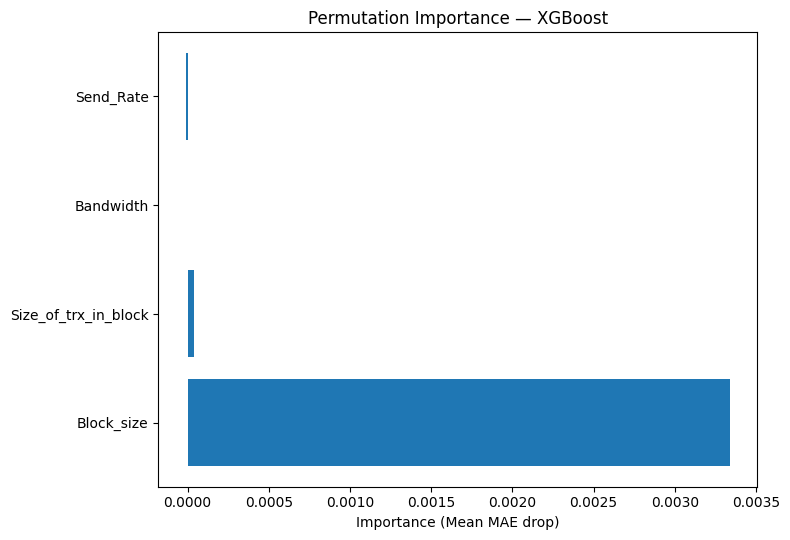

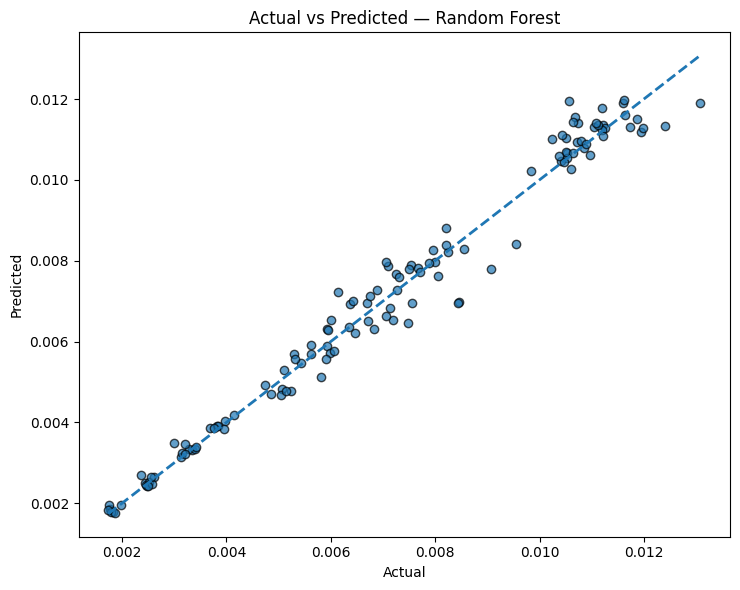

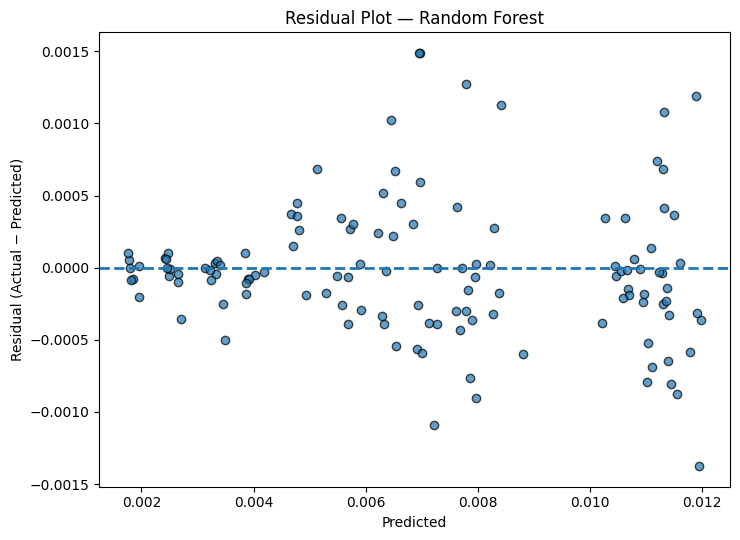

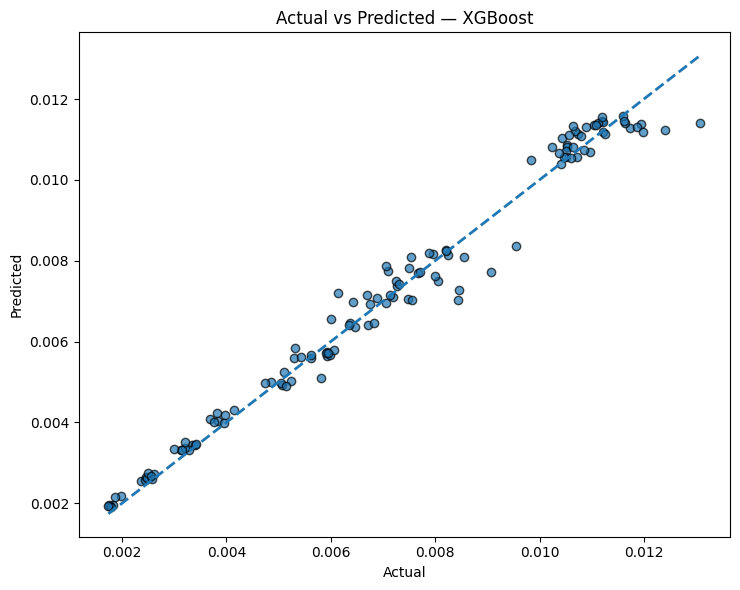

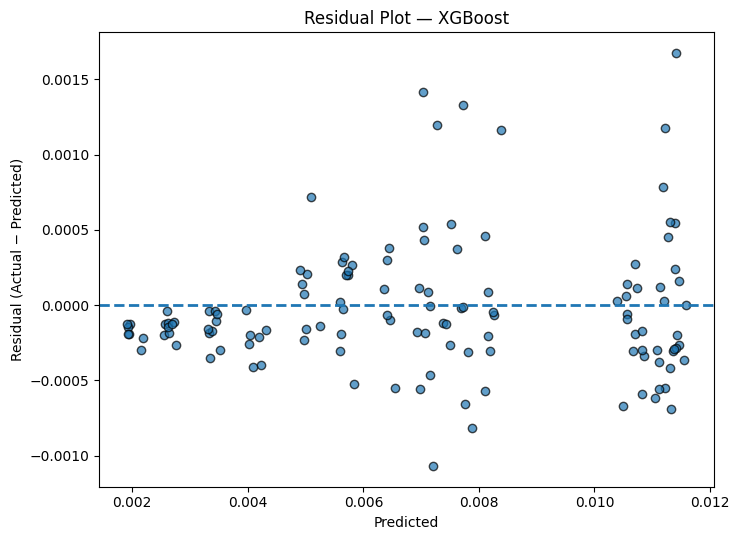

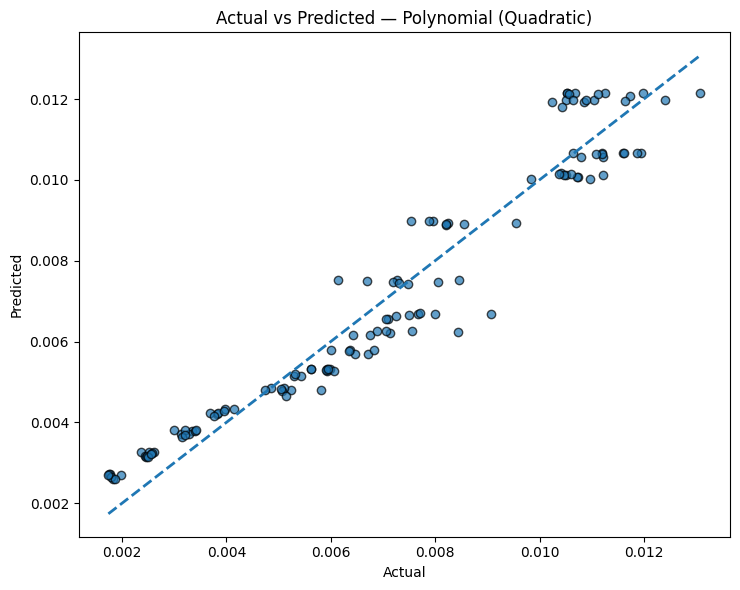

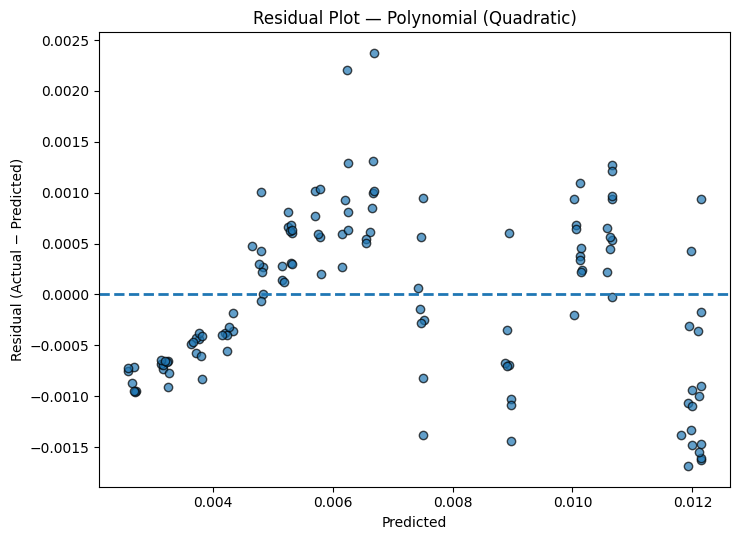

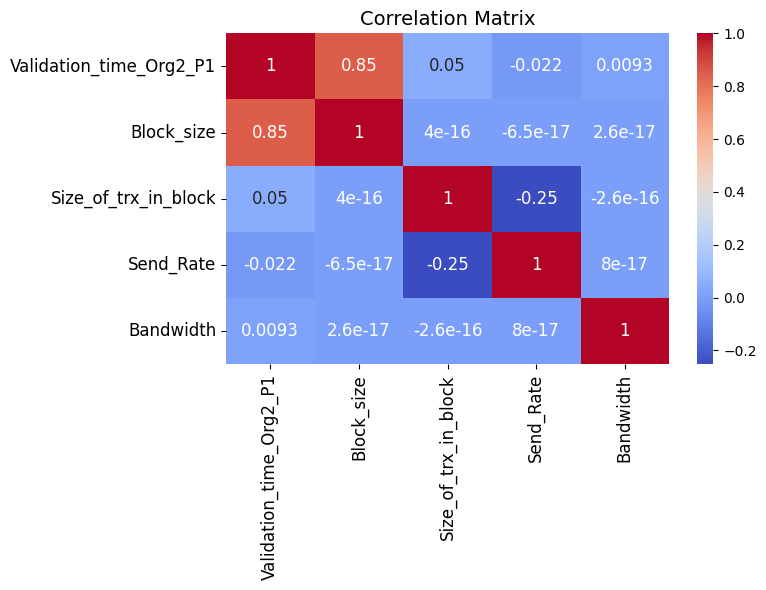

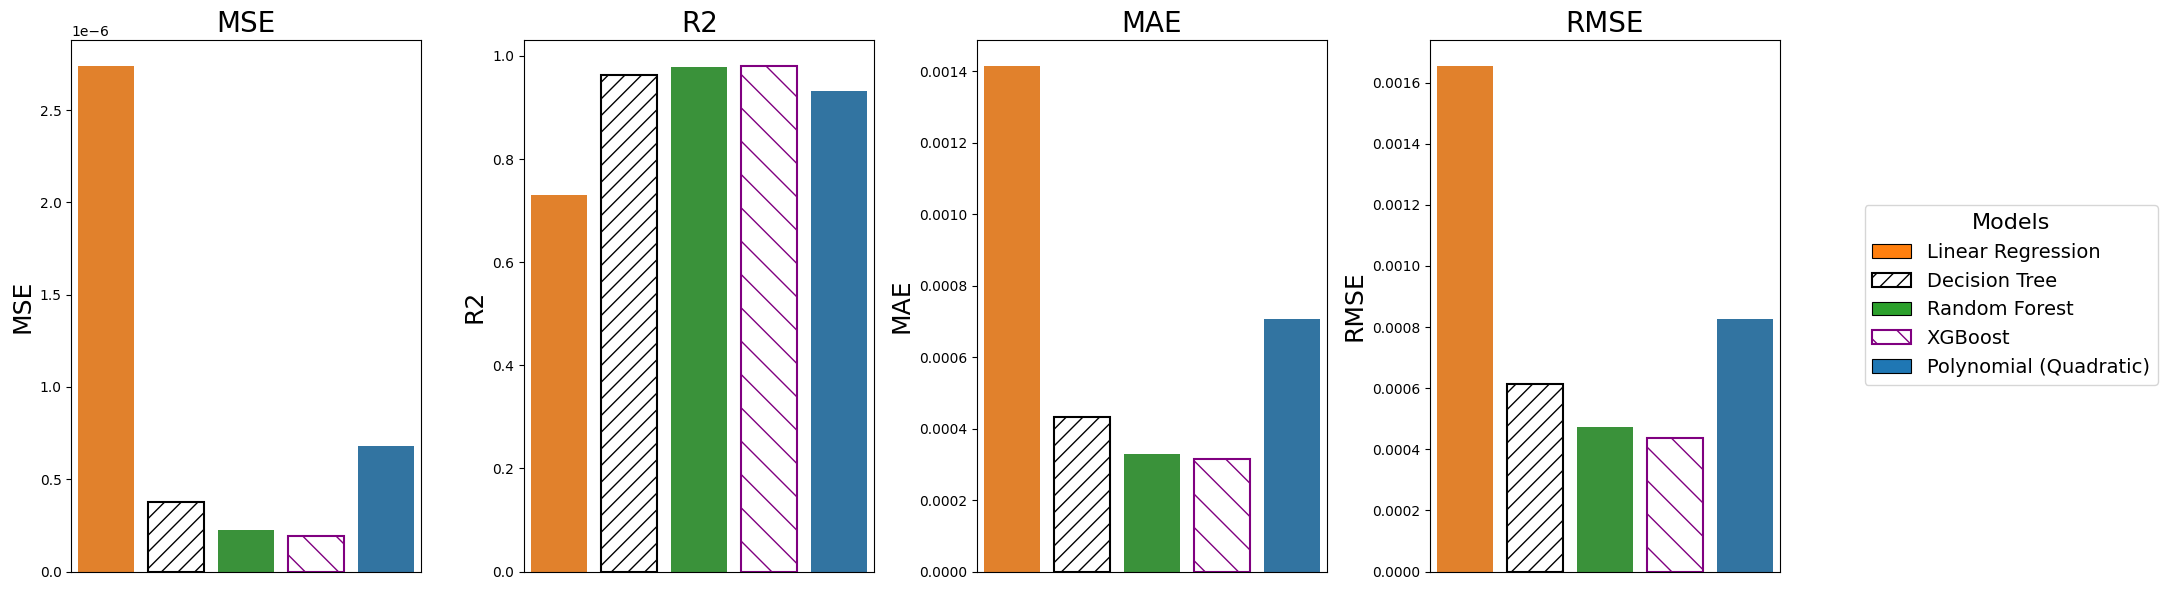

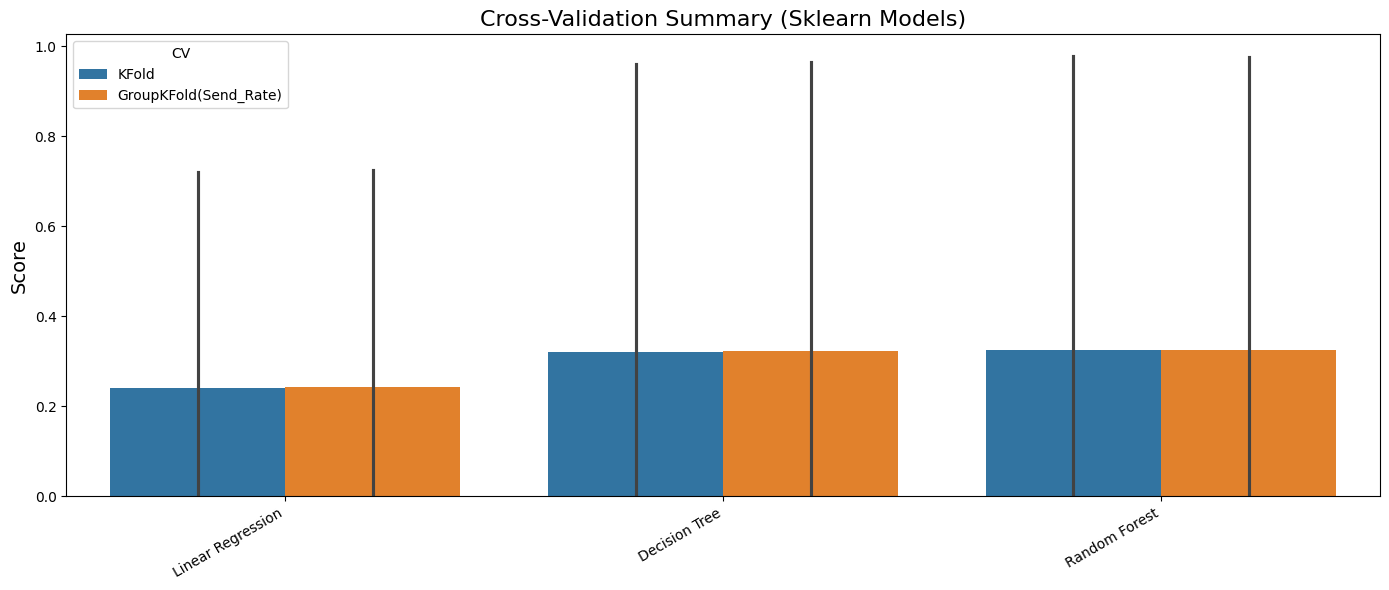


Saved models and quadratic artifacts successfully.


In [8]:
 #all model for peer0-Org1 validation time v2  



import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
plt.rcParams.update({'pdf.fonttype': 42})

from sklearn.model_selection import train_test_split, KFold, GroupKFold, cross_validate
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
from sklearn.dummy import DummyRegressor

from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor, HistGradientBoostingRegressor
from sklearn.inspection import permutation_importance

from sklearn.preprocessing import StandardScaler

from scipy.optimize import curve_fit
import xgboost as xgb

import matplotlib.patches as mpatches


# -----------------------------
# Helper metrics + plotting
# -----------------------------
def mean_absolute_percentage_error_safe(y_true, y_pred):
    """MAPE (%) ignoring zero targets to avoid division by zero."""
    y_true = np.asarray(y_true)
    y_pred = np.asarray(y_pred)
    mask = y_true != 0
    if mask.sum() == 0:
        return np.nan
    return float(np.mean(np.abs((y_true[mask] - y_pred[mask]) / y_true[mask])) * 100.0)

def metrics_dict(y_true, y_pred):
    """Return standard regression metrics in a consistent dict."""
    mse = mean_squared_error(y_true, y_pred)
    rmse = float(np.sqrt(mse))
    mae = mean_absolute_error(y_true, y_pred)
    r2 = r2_score(y_true, y_pred)
    mape = mean_absolute_percentage_error_safe(y_true, y_pred)
    return {"MAE": float(mae), "RMSE": rmse, "MSE": float(mse), "R2": float(r2), "MAPE(%)": float(mape)}

def plot_actual_vs_predicted(y_true, y_pred, model_name, save_pdf=False):
    plt.figure(figsize=(7.5, 6))
    plt.scatter(y_true, y_pred, alpha=0.7, edgecolors='k')
    mn = min(np.min(y_true), np.min(y_pred))
    mx = max(np.max(y_true), np.max(y_pred))
    plt.plot([mn, mx], [mn, mx], '--', linewidth=2)
    plt.xlabel('Actual')
    plt.ylabel('Predicted')
    plt.title(f'Actual vs Predicted — {model_name}')
    plt.tight_layout()
    if save_pdf:
        plt.savefig(f'actual_vs_pred_{model_name.replace(" ", "_")}.pdf', dpi=600)
    plt.show()

def plot_residuals(y_true, y_pred, model_name, save_pdf=False):
    residuals = np.asarray(y_true) - np.asarray(y_pred)
    plt.figure(figsize=(7.5, 5.5))
    plt.scatter(y_pred, residuals, alpha=0.7, edgecolors='k')
    plt.axhline(0, linestyle='--', linewidth=2)
    plt.xlabel('Predicted')
    plt.ylabel('Residual (Actual − Predicted)')
    plt.title(f'Residual Plot — {model_name}')
    plt.tight_layout()
    if save_pdf:
        plt.savefig(f'residuals_{model_name.replace(" ", "_")}.pdf', dpi=600)
    plt.show()

def styled_metric_bars(plot_df, metric_names, title, filename_pdf, model_colors, hatch_rules):
    """
    Publication-friendly bar chart (one row per model, one panel per metric).
    Uses consistent colors and hatches for selected models.
    """
    melted = plot_df.melt(id_vars='Models', value_vars=metric_names, var_name='Metric', value_name='Score')

    plt.figure(figsize=(18, 6))
    for i, metric in enumerate(metric_names, 1):
        plt.subplot(1, len(metric_names), i)
        ax = sns.barplot(
            x='Models', y='Score',
            data=melted.query("Metric == @metric"),
            palette=[model_colors.get(m, '#FFFFFF') for m in plot_df['Models'].tolist()],
            hue='Models', dodge=False, legend=False
        )

        # Apply hatches/edges
        for bar, model in zip(ax.patches, plot_df['Models'].tolist()):
            hatch, face_none, edge_color, lw = hatch_rules.get(model, ("", False, None, 0.8))
            bar.set_hatch(hatch)

            if face_none:
                bar.set_facecolor('none')
            if edge_color is not None:
                bar.set_edgecolor(edge_color)
            bar.set_linewidth(lw)

        plt.title(metric, fontsize=20)
        plt.ylabel(metric, fontsize=18)
        plt.xlabel('')
        plt.xticks([], [])  # clean style like your old plot

    # Legend (custom, consistent with styles)
    legend_handles = []
    for m in plot_df['Models'].tolist():
        hatch, face_none, edge_color, lw = hatch_rules.get(m, ("", False, "black", 0.8))
        fc = 'none' if face_none else model_colors.get(m, '#FFFFFF')
        ec = edge_color if edge_color is not None else 'black'
        legend_handles.append(mpatches.Patch(facecolor=fc, edgecolor=ec, linewidth=lw, hatch=hatch, label=m))

    plt.gcf().legend(
        handles=legend_handles,
        loc='center',
        bbox_to_anchor=(1.12, 0.5),
        fontsize=14,
        title='Models',
        title_fontsize=16
    )

    plt.tight_layout()
    plt.savefig(filename_pdf, format='pdf', dpi=600, bbox_inches='tight')
    plt.show()


# -----------------------------
# 0) Data / Features
# -----------------------------
# df must exist already
# df.head()

feature_cols = ['Block_size', 'Size_of_trx_in_block', 'Send_Rate', 'Bandwidth']
target_col = 'Validation_time_Org2_P1'

X = df[feature_cols].copy()
y = df[target_col].copy()

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)


# -----------------------------
# 1) Baselines (sanity checks)
# -----------------------------
baseline_mean = DummyRegressor(strategy="mean")
baseline_mean.fit(X_train, y_train)
pred_mean = baseline_mean.predict(X_test)
print("Baseline (mean):", metrics_dict(y_test, pred_mean))

baseline_block_only = LinearRegression()
baseline_block_only.fit(X_train[['Block_size']], y_train)
pred_block_only = baseline_block_only.predict(X_test[['Block_size']])
print("Baseline (Block_size only):", metrics_dict(y_test, pred_block_only))


# -----------------------------
# 2) Train models (same split)
# -----------------------------
models = {
    "Linear Regression": LinearRegression(),
    "Decision Tree": DecisionTreeRegressor(random_state=42),
    "Random Forest": RandomForestRegressor(n_estimators=300, random_state=42),
    # XGBoost: keep sklearn wrapper for train/test evaluation
    "XGBoost": xgb.XGBRegressor(
        objective='reg:squarederror',
        random_state=42,
        n_estimators=500,
        learning_rate=0.05,
        max_depth=6,
        subsample=0.9,
        colsample_bytree=0.9
    ),
}

test_results = {}
y_preds = {}

for name, mdl in models.items():
    mdl.fit(X_train, y_train)
    pred = mdl.predict(X_test)
    y_preds[name] = pred
    test_results[name] = metrics_dict(y_test, pred)

print("\n=== Test-set results (single split) ===")
for name in models.keys():
    r = test_results[name]
    print(f"\n{name}:")
    print(f"  MAE:     {r['MAE']:.10f}")
    print(f"  RMSE:    {r['RMSE']:.10f}")
    print(f"  MSE:     {r['MSE']:.10e}")
    print(f"  R2:      {r['R2']:.6f}")
    print(f"  MAPE(%): {r['MAPE(%)']:.4f}")


# -----------------------------
# 3) Quadratic regression (2 features) without leakage (curve_fit)
# -----------------------------
# This is a parametric baseline you can interpret and print as an equation.
quad_features = ['Block_size', 'Send_Rate']

def quadratic_model(X_arr, a, b, c, d, e, f):
    x1, x2 = X_arr
    return a * x1**2 + b * x1 * x2 + c * x2**2 + d * x1 + e * x2 + f

scaler_quad = StandardScaler()
X_train_q = scaler_quad.fit_transform(X_train[quad_features])
X_test_q = scaler_quad.transform(X_test[quad_features])

params, covariance = curve_fit(quadratic_model, X_train_q.T, y_train.values)
a, b, c, d, e, f = params

pred_quad = quadratic_model(X_test_q.T, *params)
test_results["Polynomial (Quadratic)"] = metrics_dict(y_test, pred_quad)
y_preds["Polynomial (Quadratic)"] = pred_quad

equation_scaled = (
    f"Validation_time = ({a:.6g} * x1^2) + ({b:.6g} * x1*x2) + ({c:.6g} * x2^2) "
    f"+ ({d:.6g} * x1) + ({e:.6g} * x2) + ({f:.6g}), "
    f"where x1,x2 are StandardScaler-transformed Block_size, Send_Rate."
)

print("\nPolynomial (Quadratic) equation (on standardized features):")
print(equation_scaled)


# -----------------------------
# 4) Cross-validation (publishable stability)
# -----------------------------
scoring = {
    "MAE": "neg_mean_absolute_error",
    "RMSE": "neg_root_mean_squared_error",
    "R2": "r2",
}

cv_kfold = KFold(n_splits=5, shuffle=True, random_state=42)

# GroupKFold: generalize to unseen Send_Rate conditions
groups = df["Send_Rate"].astype(str)
cv_group = GroupKFold(n_splits=min(3, df["Send_Rate"].nunique()))

cv_summary = []

# IMPORTANT: sklearn cross_validate may fail with XGBoost+new sklearn in some environments.
# To keep this script robust + publishable: we do sklearn CV for sklearn models,
# and XGBoost CV using xgb.cv (official).
for name, mdl in models.items():
    if name == "XGBoost":
        continue

    out_k = cross_validate(mdl, X, y, cv=cv_kfold, scoring=scoring, return_train_score=False)
    out_g = cross_validate(mdl, X, y, cv=cv_group, groups=groups, scoring=scoring, return_train_score=False)

    cv_summary.append({
        "Models": name,
        "CV": "KFold",
        "MAE": float(-out_k["test_MAE"].mean()),
        "RMSE": float(-out_k["test_RMSE"].mean()),
        "R2": float(out_k["test_R2"].mean()),
    })
    cv_summary.append({
        "Models": name,
        "CV": "GroupKFold(Send_Rate)",
        "MAE": float(-out_g["test_MAE"].mean()),
        "RMSE": float(-out_g["test_RMSE"].mean()),
        "R2": float(out_g["test_R2"].mean()),
    })

# XGBoost CV (robust, official)
dtrain = xgb.DMatrix(X.values, label=y.values)
params_xgb = {
    "objective": "reg:squarederror",
    "seed": 42,
    "learning_rate": 0.05,
    "max_depth": 6,
    "subsample": 0.9,
    "colsample_bytree": 0.9,
}
cv_xgb = xgb.cv(
    params=params_xgb,
    dtrain=dtrain,
    num_boost_round=800,
    nfold=5,
    metrics=("rmse",),
    early_stopping_rounds=30,
    seed=42,
    verbose_eval=False
)
xgb_rmse = float(cv_xgb["test-rmse-mean"].iloc[-1])

print("\nXGBoost 5-fold CV (xgb.cv):")
print("  RMSE mean (last):", xgb_rmse)
print("  RMSE std  (last):", float(cv_xgb["test-rmse-std"].iloc[-1]))


cv_df = pd.DataFrame(cv_summary)
print("\n=== CV summary (sklearn models) ===")
print(cv_df)


# -----------------------------
# 5) Permutation importance (more reliable than tree impurity importance)
# -----------------------------
# Choose a best model for importance

# Pick best model by lowest RMSE on the test set
best_model_name = min(test_results.keys(), key=lambda m: test_results[m]["RMSE"])

# Only sklearn models are in `models` (Quadratic isn't), so handle that case
if best_model_name in models:
    best_model = models[best_model_name]
else:
    best_model = None  # Quadratic

print("\nBest model (by Test RMSE):", best_model_name, test_results[best_model_name])

perm = permutation_importance(
    best_model,
    X_test, y_test,
    n_repeats=25,
    random_state=42,
    scoring="neg_mean_absolute_error"
)

perm_imp = pd.DataFrame({
    "Feature": X_test.columns,
    "ImportanceMean(MAE drop)": perm.importances_mean,
    "ImportanceStd": perm.importances_std
}).sort_values("ImportanceMean(MAE drop)", ascending=False)

print("\nPermutation importance (MAE drop):")
print(perm_imp)

# Plot permutation importances
plt.figure(figsize=(8, 5.5))
plt.barh(perm_imp["Feature"], perm_imp["ImportanceMean(MAE drop)"])
plt.xlabel("Importance (Mean MAE drop)")
plt.title(f"Permutation Importance — {best_model_name}")
plt.tight_layout()
plt.savefig("permutation_importance.pdf", dpi=600)
plt.show()


# -----------------------------
# 6) Publication plots
# -----------------------------
# 6.1 Actual vs predicted + residuals (pick top models)
for nm in ["Random Forest", "XGBoost", "Polynomial (Quadratic)"]:
    plot_actual_vs_predicted(y_test, y_preds[nm], nm, save_pdf=True)
    plot_residuals(y_test, y_preds[nm], nm, save_pdf=True)

# 6.2 Keep your correlation plot (optional)
corr_cols = [target_col] + feature_cols
correlation_matrix = df[corr_cols].corr()
plt.figure(figsize=(8, 6))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', annot_kws={"size": 12})
plt.title("Correlation Matrix", fontsize=14)
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)
plt.tight_layout()
plt.savefig('validation_correlation_matrix.pdf', format='pdf', dpi=600)
plt.show()

# 6.3 Metric comparison plots (bars) in your style (colors + hatches)
# Build a single test-results table for plotting
plot_models_order = [
    "Linear Regression",
    "Decision Tree",
    "Random Forest",
    "XGBoost",
    "Polynomial (Quadratic)"
]
plot_table = pd.DataFrame([
    {"Models": m,
     "MSE": test_results[m]["MSE"],
     "R2": test_results[m]["R2"],
     "MAPE": test_results[m]["MAPE(%)"],
     "MAE": test_results[m]["MAE"],
     "RMSE": test_results[m]["RMSE"]}
    for m in plot_models_order
])

# Colors 
model_colors = {
    "Linear Regression": "#ff7f0e",
    "Decision Tree": "none",
    "Random Forest": "#2ca02c",
    "XGBoost": "none",
    "Polynomial (Quadratic)": "#1f77b4",
}

# Hatch rules: (hatch, face_none, edge_color, linewidth)
hatch_rules = {
    "Decision Tree": ("//", True, "black", 1.5),
    "XGBoost": ("\\", True, "#800080", 1.5),
    # others default
}

# Plot A: your original trio (MSE, R2, MAPE)
styled_metric_bars(
    plot_df=plot_table[["Models", "MSE", "R2", "MAE", "RMSE"]],
    metric_names=["MSE", "R2","MAE", "RMSE"],
    title="Model Comparison (Test Set)",
    filename_pdf="validation_models_mse_r2_mape.pdf",
    model_colors=model_colors,
    hatch_rules=hatch_rules
)


# 6.4 CV summary plot (KFold vs GroupKFold)
if not cv_df.empty:
    # Pivot into long format for plotting
    cv_plot = cv_df.melt(id_vars=["Models", "CV"], value_vars=["MAE", "RMSE", "R2"],
                         var_name="Metric", value_name="Score")

    plt.figure(figsize=(14, 6))
    ax = sns.barplot(data=cv_plot, x="Models", y="Score", hue="CV")
    plt.title("Cross-Validation Summary (Sklearn Models)", fontsize=16)
    plt.ylabel("Score", fontsize=14)
    plt.xlabel("")
    plt.xticks(rotation=30, ha="right")
    plt.tight_layout()
    plt.savefig("cv_summary.pdf", dpi=600)
    plt.show()


# -----------------------------
# 7) Save fitted models/objects (for reuse)
# -----------------------------
import joblib

joblib.dump(models["Linear Regression"], "VP1Org2_linear_model.pkl")
joblib.dump(models["Decision Tree"], "VP1Org2_tree_model.pkl")
joblib.dump(models["Random Forest"], "VP1Org2_forest_model.pkl")
joblib.dump(models["XGBoost"], "VP1Org2_xgboost_model.pkl")

# Quadratic params + scaler for later prediction
joblib.dump(params, "VP1Org2_quadratic_params.pkl")
joblib.dump(scaler_quad, "VP1Org2_quadratic_scaler.pkl")

print("\nSaved models and quadratic artifacts successfully.")

